In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (f1_score, confusion_matrix, classification_report,
                             precision_recall_curve, auc, average_precision_score)
from sklearn.model_selection import StratifiedKFold, cross_val_score
import pickle
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")

Libraries loaded


In [2]:
# Load fraud data
X_train_f = pd.read_csv('data/processed/X_train_fraud.csv')
y_train_f = pd.read_csv('data/processed/y_train_fraud.csv').squeeze()
X_test_f  = pd.read_csv('data/processed/X_test_fraud.csv')
y_test_f  = pd.read_csv('data/processed/y_test_fraud.csv').squeeze()

# Load creditcard data
X_train_cc = pd.read_csv('data/processed/X_train_creditcard.csv')
y_train_cc = pd.read_csv('data/processed/y_train_creditcard.csv').squeeze()
X_test_cc  = pd.read_csv('data/processed/X_test_creditcard.csv')
y_test_cc  = pd.read_csv('data/processed/y_test_creditcard.csv').squeeze()

print("Fraud train:", X_train_f.shape)
print("Creditcard train:", X_train_cc.shape)

Fraud train: (219136, 14)
Creditcard train: (453204, 30)


In [3]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    f1 = f1_score(y_test, y_pred)
    ap = average_precision_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"\n=== {model_name} ===")
    print(f"F1 Score:  {f1:.4f}")
    print(f"AUC-PR:    {ap:.4f}")
    print(f"Confusion Matrix:\n{cm}")
    print(classification_report(y_test, y_pred))
    
    return {'model': model_name, 'f1': f1, 'auc_pr': ap}

In [4]:
# Logistic Regression - Fraud Data
print("Training Logistic Regression on Fraud Data...")
lr_fraud = LogisticRegression(max_iter=1000, random_state=42)
lr_fraud.fit(X_train_f, y_train_f)
lr_fraud_results = evaluate_model(lr_fraud, X_test_f, y_test_f, "LR - Fraud Data")

Training Logistic Regression on Fraud Data...

=== LR - Fraud Data ===
F1 Score:  0.2706
AUC-PR:    0.4169
Confusion Matrix:
[[17692  9701]
 [  869  1961]]
              precision    recall  f1-score   support

           0       0.95      0.65      0.77     27393
           1       0.17      0.69      0.27      2830

    accuracy                           0.65     30223
   macro avg       0.56      0.67      0.52     30223
weighted avg       0.88      0.65      0.72     30223



In [5]:
# Logistic Regression - Credit Card
print("Training Logistic Regression on Credit Card Data...")
lr_cc = LogisticRegression(max_iter=1000, random_state=42)
lr_cc.fit(X_train_cc, y_train_cc)
lr_cc_results = evaluate_model(lr_cc, X_test_cc, y_test_cc, "LR - Credit Card")

Training Logistic Regression on Credit Card Data...

=== LR - Credit Card ===
F1 Score:  0.1000
AUC-PR:    0.6750
Confusion Matrix:
[[55169  1482]
 [   12    83]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



In [6]:
# XGBoost - Fraud Data
print("Training XGBoost on Fraud Data...")
xgb_fraud = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_fraud.fit(X_train_f, y_train_f)
xgb_fraud_results = evaluate_model(xgb_fraud, X_test_f, y_test_f, "XGBoost - Fraud Data")

Training XGBoost on Fraud Data...

=== XGBoost - Fraud Data ===
F1 Score:  0.6783
AUC-PR:    0.6051
Confusion Matrix:
[[27347    46]
 [ 1354  1476]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.98     27393
           1       0.97      0.52      0.68      2830

    accuracy                           0.95     30223
   macro avg       0.96      0.76      0.83     30223
weighted avg       0.95      0.95      0.95     30223



In [7]:
# XGBoost - Credit Card
print("Training XGBoost on Credit Card Data...")
xgb_cc = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_cc.fit(X_train_cc, y_train_cc)
xgb_cc_results = evaluate_model(xgb_cc, X_test_cc, y_test_cc, "XGBoost - Credit Card")

Training XGBoost on Credit Card Data...

=== XGBoost - Credit Card ===
F1 Score:  0.5130
AUC-PR:    0.7965
Confusion Matrix:
[[56517   134]
 [   16    79]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.37      0.83      0.51        95

    accuracy                           1.00     56746
   macro avg       0.69      0.91      0.76     56746
weighted avg       1.00      1.00      1.00     56746



In [8]:
# Stratified K-Fold Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=== Cross Validation - XGBoost Fraud Data ===")
cv_f1_fraud = cross_val_score(
    XGBClassifier(n_estimators=100, max_depth=6, random_state=42, verbosity=0, eval_metric='logloss'),
    X_train_f, y_train_f, cv=skf, scoring='f1'
)
print(f"F1 per fold: {cv_f1_fraud.round(4)}")
print(f"Mean F1: {cv_f1_fraud.mean():.4f} +/- {cv_f1_fraud.std():.4f}")

print("\n=== Cross Validation - XGBoost Credit Card ===")
cv_f1_cc = cross_val_score(
    XGBClassifier(n_estimators=100, max_depth=6, random_state=42, verbosity=0, eval_metric='logloss'),
    X_train_cc, y_train_cc, cv=skf, scoring='f1'
)
print(f"F1 per fold: {cv_f1_cc.round(4)}")
print(f"Mean F1: {cv_f1_cc.mean():.4f} +/- {cv_f1_cc.std():.4f}")

=== Cross Validation - XGBoost Fraud Data ===
F1 per fold: [0.9562 0.9594 0.9572 0.9581 0.9588]
Mean F1: 0.9579 +/- 0.0011

=== Cross Validation - XGBoost Credit Card ===
F1 per fold: [0.9998 0.9998 0.9997 0.9998 0.9998]
Mean F1: 0.9998 +/- 0.0000


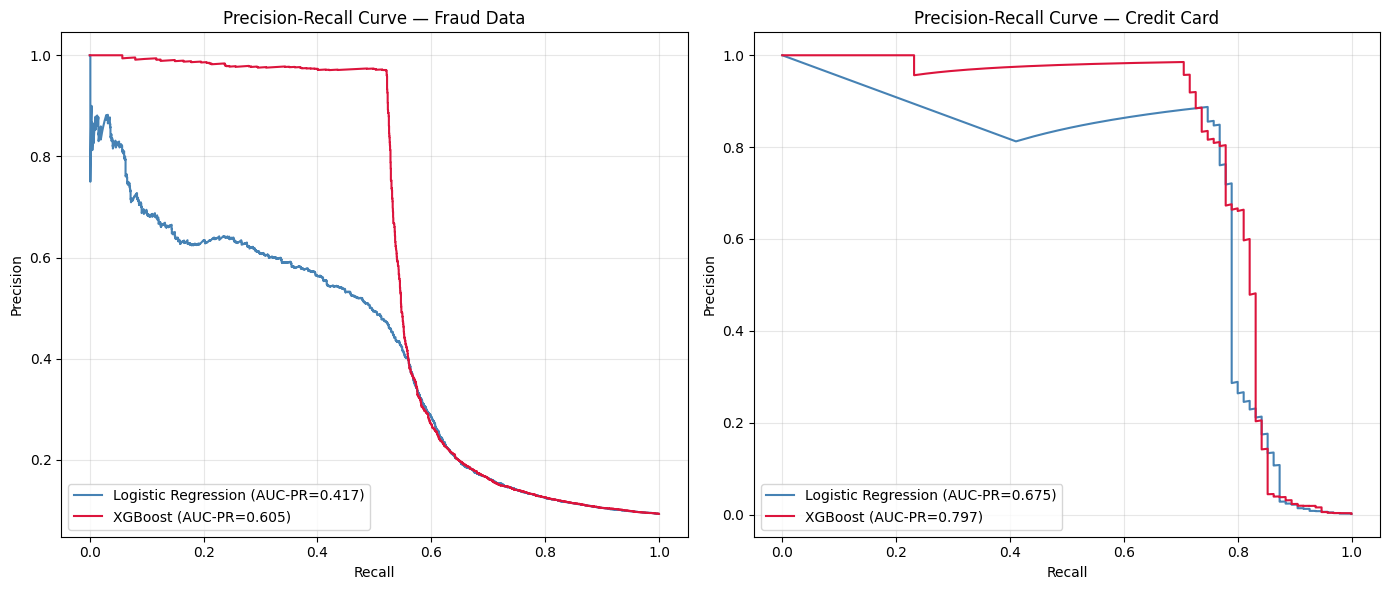

In [9]:
# Precision-Recall Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (model, X_test, y_test, title) in zip(axes, [
    (lr_fraud,  X_test_f,  y_test_f,  'Fraud Data'),
    (lr_cc,     X_test_cc, y_test_cc, 'Credit Card'),
]):
    for m, name, color in [
        (lr_fraud if title == 'Fraud Data' else lr_cc, 'Logistic Regression', 'steelblue'),
        (xgb_fraud if title == 'Fraud Data' else xgb_cc, 'XGBoost', 'crimson'),
    ]:
        prob = m.predict_proba(X_test)[:, 1]
        prec, rec, _ = precision_recall_curve(y_test, prob)
        ap = average_precision_score(y_test, prob)
        ax.plot(rec, prec, label=f'{name} (AUC-PR={ap:.3f})', color=color)
    
    ax.set_title(f'Precision-Recall Curve — {title}')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/processed/precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Model comparison table
results = pd.DataFrame([
    lr_fraud_results,
    xgb_fraud_results,
    lr_cc_results,
    xgb_cc_results
])

print("=== MODEL COMPARISON TABLE ===")
print(results.to_string(index=False))

results.to_csv('data/processed/model_comparison.csv', index=False)

=== MODEL COMPARISON TABLE ===
                model       f1   auc_pr
      LR - Fraud Data 0.270632 0.416895
 XGBoost - Fraud Data 0.678309 0.605091
     LR - Credit Card 0.100000 0.675041
XGBoost - Credit Card 0.512987 0.796512


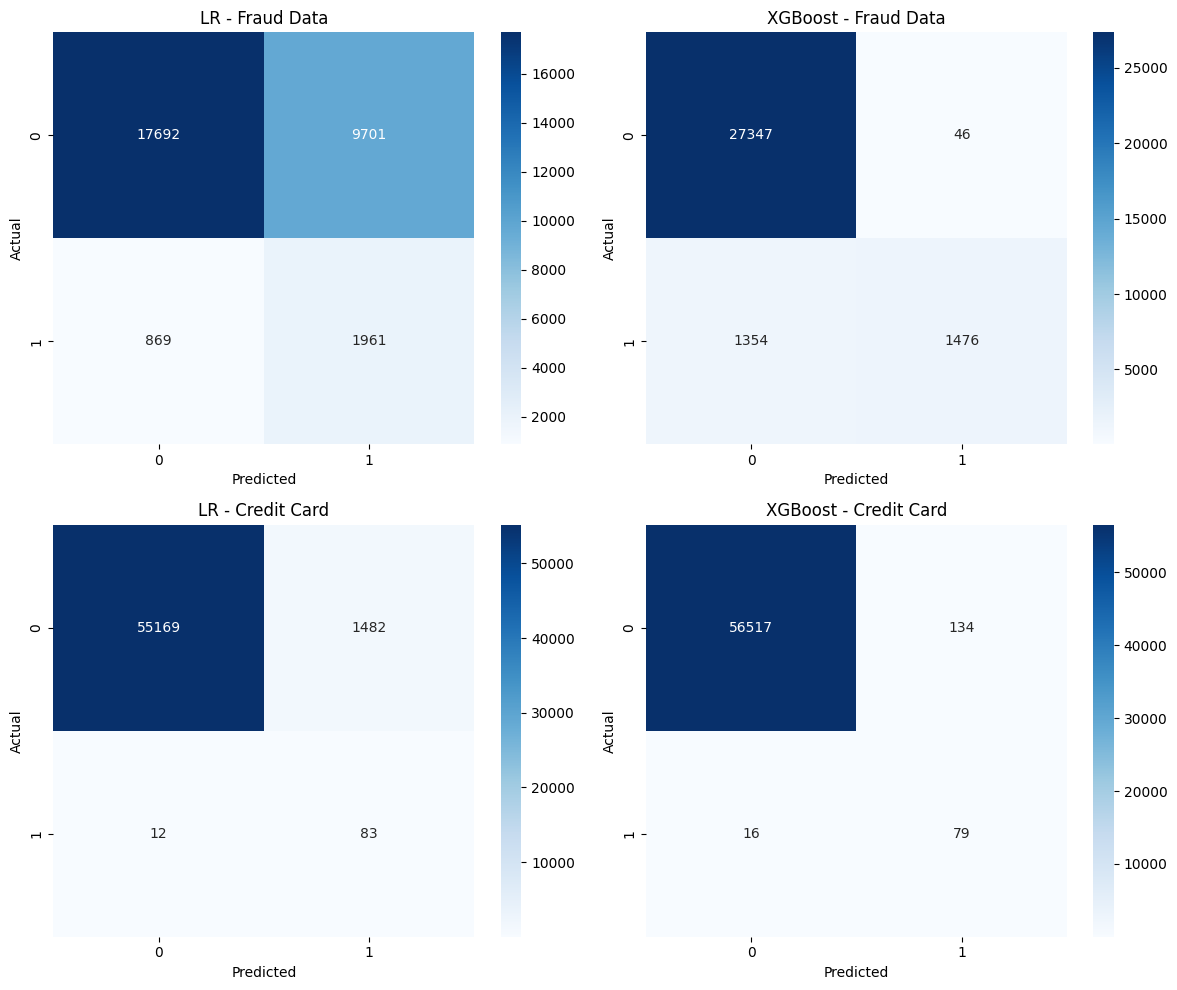

In [11]:
# Confusion matrix plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (model, X_test, y_test, title) in zip(axes.flatten(), [
    (lr_fraud,  X_test_f,  y_test_f,  'LR - Fraud Data'),
    (xgb_fraud, X_test_f,  y_test_f,  'XGBoost - Fraud Data'),
    (lr_cc,     X_test_cc, y_test_cc, 'LR - Credit Card'),
    (xgb_cc,    X_test_cc, y_test_cc, 'XGBoost - Credit Card'),
]):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('data/processed/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Save best models
with open('models/xgb_fraud.pkl', 'wb') as f:
    pickle.dump(xgb_fraud, f)

with open('models/xgb_creditcard.pkl', 'wb') as f:
    pickle.dump(xgb_cc, f)

with open('models/lr_fraud.pkl', 'wb') as f:
    pickle.dump(lr_fraud, f)

with open('models/lr_creditcard.pkl', 'wb') as f:
    pickle.dump(lr_cc, f)

print("All models saved to models/ folder!")

All models saved to models/ folder!
